# Crop Recommendation System Using CNN

# Install Libraries

In [22]:
import numpy as np
import pandas as pd

# Load Dataset

In [23]:
df = pd.read_csv('/kaggle/input/datasets/varshitanalluri/crop-recommendation-dataset/Crop_Recommendation.csv')

# Build Model

# CNN

In [29]:
# =========================
# CNN MODEL, TRAINING & EVALUATION
# =========================

import os
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, Add,
    Flatten, Dense, Dropout, concatenate
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

# -------------------------
# 1. Create save directory
# -------------------------
save_dir = "/kaggle/working/"
os.makedirs(save_dir, exist_ok=True)

# -------------------------
# 2. Label Encoding (Target)
# -------------------------
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Save label encoder
encoder_path = os.path.join(save_dir, "crop_label_encoder.pkl")
joblib.dump(label_encoder, encoder_path)

# One-hot encode labels
y_categorical = to_categorical(y_encoded)

# -------------------------
# 3. Feature Scaling
# -------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Save scaler
scaler_path = os.path.join(save_dir, "feature_scaler.pkl")
joblib.dump(scaler, scaler_path)

# -------------------------
# 4. Reshape for CNN
# -------------------------
X_cnn = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)

# -------------------------
# 5. Train–Test Split
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_cnn, y_categorical,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

# -------------------------
# 6. CNN Architecture
# -------------------------
input_layer = Input(shape=(X_train.shape[1], 1))

# Inception-style block
conv1 = Conv1D(64, kernel_size=1, activation='relu', padding='same')(input_layer)
conv3 = Conv1D(64, kernel_size=3, activation='relu', padding='same')(input_layer)
conv5 = Conv1D(64, kernel_size=5, activation='relu', padding='same')(input_layer)

inception_block = concatenate([conv1, conv3, conv5])

# Residual block
residual = Conv1D(128, 3, activation='relu', padding='same')(inception_block)
residual = Conv1D(128, 3, activation='relu', padding='same')(residual)

shortcut = Conv1D(128, 1, padding='same')(inception_block)
residual_output = Add()([residual, shortcut])

# Pooling
pool = MaxPooling1D(pool_size=2)(residual_output)

# Fully connected layers
flat = Flatten()(pool)
dense = Dense(128, activation='relu')(flat)
drop = Dropout(0.3)(dense)
output = Dense(y_train.shape[1], activation='softmax')(drop)

# Build model
model = Model(inputs=input_layer, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Training Shape: (1760, 7, 1)
Testing Shape: (440, 7, 1)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 7, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 7, 64)     │        128 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 7, 64)     │        256 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 7, 64)     │        384 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 7, 192)    │          0 │ conv1d_6[0][0],   │
│ (Concatenate)       │                   │            │ conv1d_7[0][0],   │
│                     │                   │            │ conv1d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 7, 128)    │     73,856 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 7, 128)    │     49,280 │ conv1d_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, 7, 128)    │     24,704 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 7, 128)    │          0 │ conv1d_10[0][0],  │
│                     │                   │            │ conv1d_11[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 3, 128)    │          0 │ add_1[0][0]       │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 384)       │          0 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     49,280 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 22)        │      2,838 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 200,726 (784.09 KB)

 Trainable params: 200,726 (784.09 KB)

 Non-trainable params: 0 (0.00 B)

# Train Model

In [30]:
# -------------------------
# 7. Train Model
# -------------------------
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

# -------------------------
# 8. Evaluation
# -------------------------
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

print("\nClassification Report:\n")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=label_encoder.classes_
    )
)

# -------------------------
# 9. Save Model (Modern Keras Format)
# -------------------------
model_path = os.path.join(save_dir, "crop_recommendation_CNN.keras")
model.save(model_path)

print("\nFiles Saved Successfully:")
print("Label Encoder:", encoder_path)
print("Scaler:", scaler_path)
print("Model:", model_path)

Epoch 1/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.3402 - loss: 2.2713 - val_accuracy: 0.8682 - val_loss: 0.4209
Epoch 2/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8381 - loss: 0.5033 - val_accuracy: 0.9341 - val_loss: 0.1656
Epoch 3/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9237 - loss: 0.2245 - val_accuracy: 0.9500 - val_loss: 0.1131
Epoch 4/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9382 - loss: 0.1784 - val_accuracy: 0.9727 - val_loss: 0.0908
Epoch 5/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9386 - loss: 0.1603 - val_accuracy: 0.9568 - val_loss: 0.0891
Epoch 6/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9505 - loss: 0.1220 - val_accuracy: 0.9705 - val_loss: 0.0918
Epoch 7/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9685 - loss: 0.1040 - val_accuracy: 0.9705 - val_loss: 0.0727
Epoch 8/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9679 - loss: 0.0790 - val_accuracy: 0.9682 - val_loss

# Model History

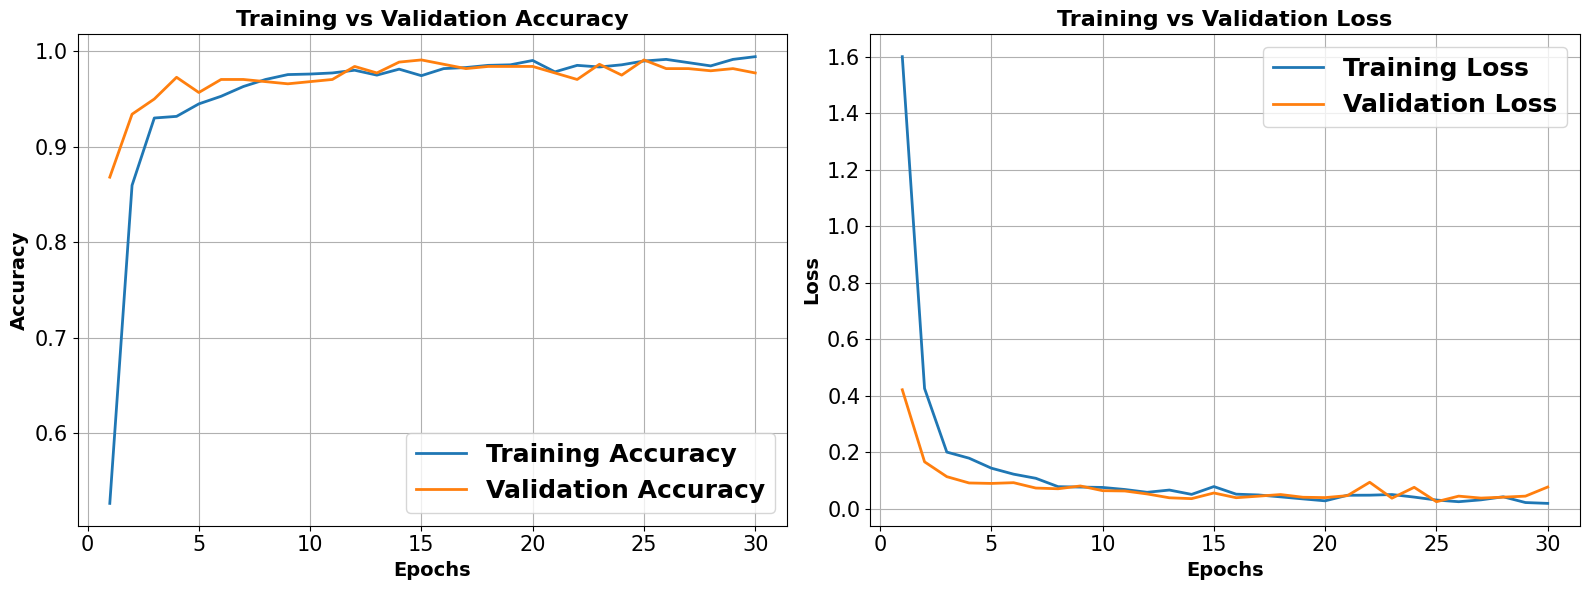

In [31]:
# =========================
# TRAINING & VALIDATION CURVES (SIDE-BY-SIDE)
# =========================

import matplotlib.pyplot as plt

# Extract history values
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(train_acc) + 1)

# Create figure with two subplots in one row
plt.figure(figsize=(16, 6))

# -------------------------
# Accuracy Plot (Left)
# -------------------------
plt.subplot(1, 2, 1)
plt.plot(epochs, train_acc, label='Training Accuracy', linewidth=2)
plt.plot(epochs, val_acc, label='Validation Accuracy', linewidth=2)
plt.xlabel('Epochs', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy', fontsize=14, fontweight='bold')
# Increase the font size for x and y ticks
plt.xticks(fontsize=15, fontweight='normal')
plt.yticks(fontsize=15, fontweight='normal')
plt.title('Training vs Validation Accuracy', fontsize=16, fontweight='bold')
plt.legend(loc='best', prop={'size': 18, 'weight': 'bold'})
plt.grid(True)

# -------------------------
# Loss Plot (Right)
# -------------------------
plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, label='Training Loss', linewidth=2)
plt.plot(epochs, val_loss, label='Validation Loss', linewidth=2)
plt.xlabel('Epochs', fontsize=14, fontweight='bold')
plt.ylabel('Loss', fontsize=14, fontweight='bold')
# Increase the font size for x and y ticks
plt.xticks(fontsize=15, fontweight='normal')
plt.yticks(fontsize=15, fontweight='normal')
plt.title('Training vs Validation Loss', fontsize=16, fontweight='bold')
plt.legend(loc='best', prop={'size': 18, 'weight': 'bold'})
plt.grid(True)

# Adjust layout
plt.tight_layout()
plt.show()


# ROC Curve

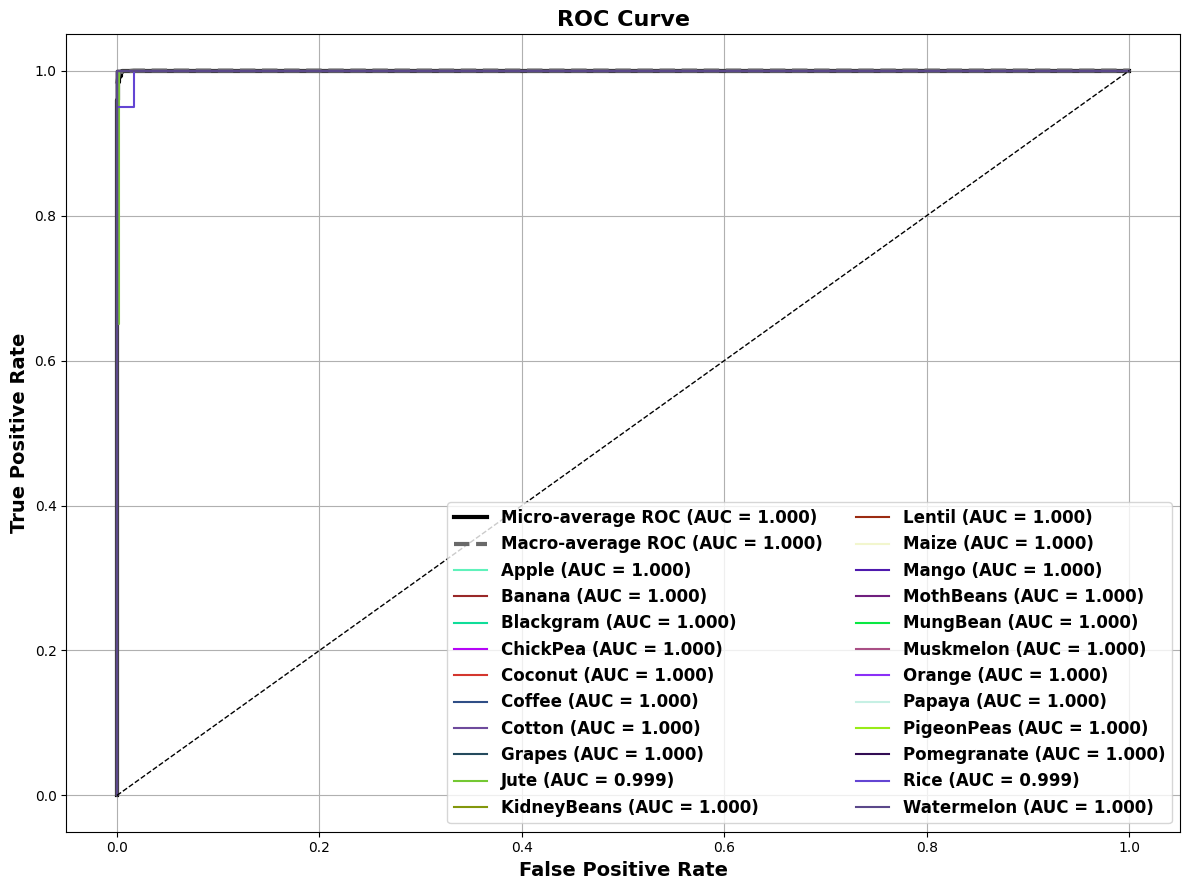

In [32]:
# =========================
# MULTI-CLASS ROC CURVES
# =========================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Number of classes
n_classes = y_test.shape[1]

# Compute ROC curve and ROC area for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# -------------------------
# Micro-average ROC
# -------------------------
fpr["micro"], tpr["micro"], _ = roc_curve(
    y_test.ravel(), y_pred_probs.ravel()
)
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# -------------------------
# Macro-average ROC
# -------------------------
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# -------------------------
# Generate UNIQUE random colors
# -------------------------
np.random.seed(42)  # reproducible
colors = np.random.rand(n_classes, 3)

# -------------------------
# Plot ROC Curves
# -------------------------
plt.figure(figsize=(12, 9))

# Micro & Macro ROC
plt.plot(
    fpr["micro"], tpr["micro"],
    label=f"Micro-average ROC (AUC = {roc_auc['micro']:.3f})",
    linewidth=3, color='black'
)

plt.plot(
    fpr["macro"], tpr["macro"],
    label=f"Macro-average ROC (AUC = {roc_auc['macro']:.3f})",
    linewidth=3, linestyle='--', color='dimgray'
)

# Class-wise ROC curves
for i in range(n_classes):
    plt.plot(
        fpr[i], tpr[i],
        color=colors[i],
        linewidth=1.5,
        label=f"{label_encoder.classes_[i]} (AUC = {roc_auc[i]:.3f})"
    )

# Diagonal
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)

# Formatting
plt.xlabel('False Positive Rate', fontsize=14, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=14, fontweight='bold')
plt.title('ROC Curve', fontsize=16, fontweight='bold')
plt.legend(loc='best', ncol=2, prop={'size': 12, 'weight': 'bold'})
plt.grid(True)
plt.tight_layout()
plt.show()


# Confusion Matrix

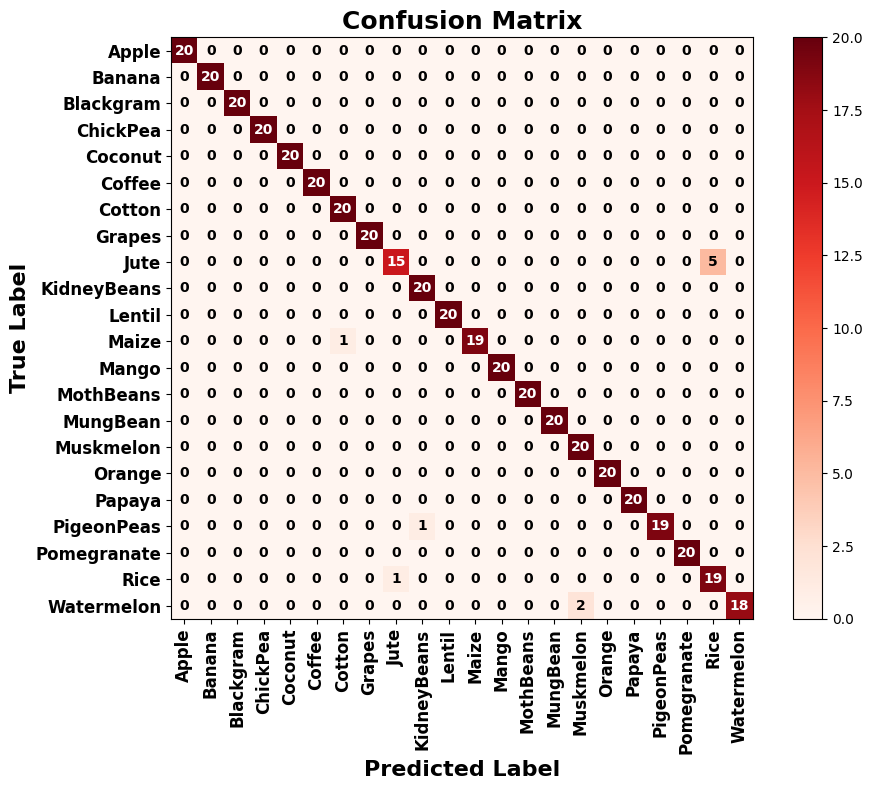

In [33]:
# =========================
# CONFUSION MATRIX 
# =========================


import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score,
    matthews_corrcoef
)

# Compute Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
classes = label_encoder.classes_

plt.figure(figsize=(10, 8))
plt.imshow(cm, cmap='Reds')
plt.title("Confusion Matrix", fontsize=18, fontweight='bold')
plt.xlabel("Predicted Label", fontsize=16, fontweight='bold')
plt.ylabel("True Label", fontsize=16, fontweight='bold')
plt.colorbar()

# Tick labels
plt.xticks(range(len(classes)), classes, rotation=90, fontsize=12, fontweight='bold')
plt.yticks(range(len(classes)), classes, fontsize=12, fontweight='bold')

# Annotate each cell
threshold = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, format(cm[i, j], 'd'),
            ha="center", va="center",
            fontsize=10, fontweight='bold',
            color="white" if cm[i, j] > threshold else "black"
        )

plt.tight_layout()
plt.show()


# -------------------------
# 2. Basic Metrics
# -------------------------
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')
error_rate = 1 - accuracy
mcc = matthews_corrcoef(y_true, y_pred)

# -------------------------
# 3. ROC-AUC (Macro)
# -------------------------
roc_auc = roc_auc_score(y_test, y_pred_probs, average='macro', multi_class='ovr')

# -------------------------
# 4. Specificity, FPR, TPR, FNR, TNR (Macro)
# -------------------------
specificity_list = []
fpr_list = []
fnr_list = []

for i in range(len(cm)):
    TP = cm[i, i]
    FN = np.sum(cm[i, :]) - TP
    FP = np.sum(cm[:, i]) - TP
    TN = np.sum(cm) - (TP + FN + FP)

    specificity_list.append(TN / (TN + FP))
    fpr_list.append(FP / (FP + TN))
    fnr_list.append(FN / (FN + TP))

specificity = np.mean(specificity_list)
fpr = np.mean(fpr_list)
fnr = np.mean(fnr_list)
tpr = recall          # TPR = Recall
tnr = specificity     # TNR = Specificity


# Performance Metrics

In [34]:
# -------------------------
# 5. Print All Metrics
# -------------------------
print("=============================")
print("   Performance Metrics  :")
print("=============================")
print(f"Accuracy             : {accuracy:.4f}")
print(f"Precision            : {precision:.4f}")
print(f"Recall               : {recall:.4f}")
print(f"F1-Score             : {f1:.4f}")
print(f"Specificity          : {specificity:.4f}")
print(f"Error Rate           : {error_rate:.4f}")
print(f"ROC-AUC              : {roc_auc:.4f}")
print(f"False Positive Rate  : {fpr:.4f}")
print(f"False Negative Rate  : {fnr:.4f}")
print(f"MCC                  : {mcc:.4f}")
print("=============================")

   Performance Metrics  :
Accuracy             : 0.9773
Precision            : 0.9792
Recall               : 0.9773
F1-Score             : 0.9771
Specificity          : 0.9989
Error Rate           : 0.0227
ROC-AUC              : 0.9999
False Positive Rate  : 0.0011
False Negative Rate  : 0.0227
MCC                  : 0.9763


# Prediction - Random

In [35]:
# =========================
# LOAD MODEL & PREDICT 2 SAMPLES PER CLASS (CLEAN)
# =========================

import numpy as np
import pandas as pd
import joblib
from tensorflow.keras.models import load_model

# -------------------------
# 1. Load saved artifacts
# -------------------------
model = load_model("/kaggle/working/crop_recommendation_CNN.keras")
label_encoder = joblib.load("/kaggle/working/crop_label_encoder.pkl")
scaler = joblib.load("/kaggle/working/feature_scaler.pkl")

print("Model, Encoder, and Scaler loaded successfully.\n")

# -------------------------
# 2. Select EXACTLY 2 samples from each class
# -------------------------
sample_df = pd.concat(
    [
        df[df['Crop'] == crop].sample(2, random_state=42)
        for crop in label_encoder.classes_
    ],
    ignore_index=True
)

# -------------------------
# 3. Separate features and labels
# -------------------------
X_sample = sample_df.drop("Crop", axis=1)
y_actual = sample_df["Crop"].values

# -------------------------
# 4. Preprocess samples
# -------------------------
X_scaled = scaler.transform(X_sample)
X_cnn = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)

# -------------------------
# 5. Prediction
# -------------------------
y_pred_probs = model.predict(X_cnn)
y_pred_encoded = np.argmax(y_pred_probs, axis=1)
y_pred_labels = label_encoder.inverse_transform(y_pred_encoded)

# -------------------------
# 6. Print Actual vs Predicted
# -------------------------
print("========= ACTUAL vs PREDICTED (2 SAMPLES PER CLASS) =========\n")

for i in range(len(sample_df)):
    print(f"Sample {i+1}")
    print(f"Actual Crop   : {y_actual[i]}")
    print(f"Predicted Crop: {y_pred_labels[i]}")
    print("-" * 50)


Model, Encoder, and Scaler loaded successfully.

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
========= ACTUAL vs PREDICTED (2 SAMPLES PER CLASS) =========

Sample 1
Actual Crop   : Apple
Predicted Crop: Apple
--------------------------------------------------
Sample 2
Actual Crop   : Apple
Predicted Crop: Apple
--------------------------------------------------
Sample 3
Actual Crop   : Banana
Predicted Crop: Banana
--------------------------------------------------
Sample 4
Actual Crop   : Banana
Predicted Crop: Banana
--------------------------------------------------
Sample 5
Actual Crop   : Blackgram
Predicted Crop: Blackgram
--------------------------------------------------
Sample 6
Actual Crop   : Blackgram
Predicted Crop: Blackgram
--------------------------------------------------
Sample 7
Actual Crop   : ChickPea
Predicted Crop: ChickPea
--------------------------------------------------
Sample 8
Actual Crop   : ChickPea
Predicted Crop: ChickPea
------------------------------------

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Machine Learning Models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# 1. Load and Clean
df = pd.read_csv('/kaggle/input/datasets/varshitanalluri/crop-recommendation-dataset/Crop_Recommendation.csv')
df = df.drop_duplicates()

# 2. Prepare Features and Target
X = df.drop('Crop', axis=1)
y = df['Crop']

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Scale features (Essential for SVM and KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Define the 5 New Models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB()
}

Multi-Model Training and Evaluation

In [37]:
results = []

print("Training Models...")
for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)
    
    # Predict
    predictions = model.predict(X_test_scaled)
    
    # Calculate Metrics
    acc = accuracy_score(y_test, predictions)
    f1 = f1_score(y_test, predictions, average='macro')
    
    results.append({"Model": name, "Accuracy": acc, "F1-Score": f1})
    print(f"Finished {name}: Accuracy = {acc:.4f}")

# Convert results to DataFrame
comparison_df = pd.DataFrame(results)

Training Models...
Finished Random Forest: Accuracy = 0.9932


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:18:48] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Finished XGBoost: Accuracy = 0.9864
Finished SVM: Accuracy = 0.9682
Finished KNN: Accuracy = 0.9568
Finished Naive Bayes: Accuracy = 0.9955


Comparative Analysis Visualization

/tmp/ipykernel_57/3520245182.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=comparison_df, palette='viridis')


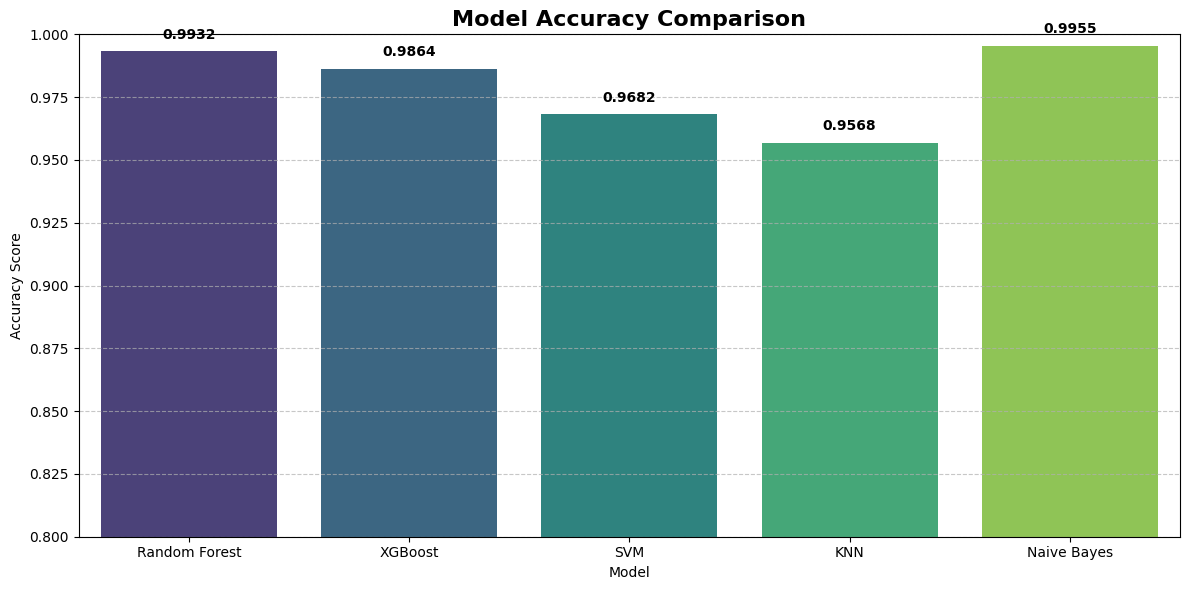


--- Final Comparative Analysis ---
           Model  Accuracy  F1-Score
4    Naive Bayes  0.995455  0.995581
0  Random Forest  0.993182  0.992637
1        XGBoost  0.986364  0.985940
2            SVM  0.968182  0.966552
3            KNN  0.956818  0.954614


In [38]:
# Set up the visualization
plt.figure(figsize=(12, 6))

# Accuracy Plot
sns.barplot(x='Model', y='Accuracy', data=comparison_df, palette='viridis')
plt.title('Model Accuracy Comparison', fontsize=16, fontweight='bold')
plt.ylim(0.8, 1.0) # Zoom in to see differences
plt.ylabel('Accuracy Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, val in enumerate(comparison_df['Accuracy']):
    plt.text(i, val + 0.005, f'{val:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Display the summary table
print("\n--- Final Comparative Analysis ---")
print(comparison_df.sort_values(by='Accuracy', ascending=False))

In [39]:
# -------------------------
# 5. Print All Metrics
# -------------------------
print("=============================")
print("   Performance Metrics  :")
print("=============================")
print(f"Accuracy             : {accuracy:.4f}")
print(f"Precision            : {precision:.4f}")
print(f"Recall               : {recall:.4f}")
print(f"F1-Score             : {f1:.4f}")
print(f"Specificity          : {specificity:.4f}")
print(f"Error Rate           : {error_rate:.4f}")
print(f"ROC-AUC              : {roc_auc:.4f}")
print(f"False Positive Rate  : {fpr:.4f}")
print(f"False Negative Rate  : {fnr:.4f}")
print(f"MCC                  : {mcc:.4f}")
print("=============================")

   Performance Metrics  :
Accuracy             : 0.9773
Precision            : 0.9792
Recall               : 0.9773
F1-Score             : 0.9956
Specificity          : 0.9989
Error Rate           : 0.0227
ROC-AUC              : 0.9999
False Positive Rate  : 0.0011
False Negative Rate  : 0.0227
MCC                  : 0.9763
